# 07 — Capstone: Full Pipeline + Ranked Recommendations
Ties 01-06 together end-to-end and produces the final action table for the paper.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd, numpy as np, joblib
import matplotlib.pyplot as plt
from _lib import (load_search_data, assert_no_window_overlap, compute_labels,
                   build_features, generate_reason_code, recommend_action,
                   FEATURE_WEEKS, LABEL_WEEKS, TEST_LABEL_WEEKS)

assert_no_window_overlap()
df = load_search_data()

Leakage check passed: feature / label / test windows are disjoint.
  feature weeks: 0-11
  label weeks (train/val target): 12-15
  test weeks (held out): 16-19


In [2]:
# Final held-out test evaluation (weeks 16-19), untouched until now
test_labels = compute_labels(df, TEST_LABEL_WEEKS)
test_features = build_features(df, FEATURE_WEEKS)  # features still only from weeks 0-11
test_data = test_features.merge(test_labels, on="page_id")

model = joblib.load("data_cache/model.joblib")
feature_cols = joblib.load("data_cache/feature_cols.joblib")

from sklearn.metrics import accuracy_score, classification_report
test_preds = model.predict(test_data[feature_cols])
print("FINAL held-out test accuracy:", round(accuracy_score(test_data["label"], test_preds), 3))
print(classification_report(test_data["label"], test_preds, zero_division=0))

FINAL held-out test accuracy: 0.536
              precision    recall  f1-score   support

   declining       0.39      0.29      0.33       107
     growing       0.23      0.17      0.19        89
      stable       0.63      0.73      0.67       304

    accuracy                           0.54       500
   macro avg       0.41      0.40      0.40       500
weighted avg       0.50      0.54      0.52       500



In [3]:
test_data["predicted_label"] = test_preds
test_data["reason_code"] = test_data.apply(generate_reason_code, axis=1)
test_data["action"] = test_data.apply(lambda r: recommend_action(r["predicted_label"], r), axis=1)

# Priority score: weight declining pages that still rank reasonably well highest
# (biggest opportunity-per-effort), then decliners generally, then stable/low-word-count.
def priority_score(row):
    score = 0
    if row["predicted_label"] == "declining":
        score += 100 - min(row["avg_position"], 100)  # higher score if still ranks well
        score += 20
    elif row["predicted_label"] == "recovering":
        score += 15
    elif row["predicted_label"] == "stable" and row["word_count"] < 500:
        score += 10
    return round(score, 1)

test_data["priority_score"] = test_data.apply(priority_score, axis=1)

In [4]:
recommendations = (test_data[test_data["priority_score"] > 0]
    [["page_id","predicted_label","avg_position","avg_ctr","word_count",
      "action","reason_code","priority_score"]]
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True))

print(f"{len(recommendations)} pages flagged for action out of {len(test_data)} total")
recommendations.head(15)

101 pages flagged for action out of 500 total


,page_id,predicted_label,avg_position,avg_ctr,word_count,action,reason_code,priority_score
0,page_0177,declining,5.366667,0.051625,1851,improve,clicks trending down within observation window...,114.6
1,page_0333,declining,5.475000,0.028883,565,improve,clicks trending down within observation window...,114.5
2,page_0001,declining,5.575000,0.023358,1263,improve,no strong signal — monitor,114.4
3,page_0010,declining,5.641667,0.035758,1533,improve,"content is 2+ years old, candidate for refresh",114.4
4,page_0080,declining,5.758333,0.031125,1396,improve,"content is 2+ years old, candidate for refresh",114.2
5,page_0253,declining,5.791667,0.032208,1760,improve,clicks trending down within observation window...,114.2
6,page_0282,declining,5.816667,0.042317,387,improve,clicks trending down within observation window,114.2
7,page_0014,declining,6.041667,0.031850,1213,improve,"content is 2+ years old, candidate for refresh",114.0
8,page_0167,declining,5.983333,0.059700,2807,improve,clicks trending down within observation window...,114.0
9,page_0219,declining,6.141667,0.030367,2212,improve,no strong signal — monitor,113.9


In [5]:
recommendations.to_csv("data_cache/ranked_recommendations.csv", index=False)
recommendations.head(50).to_csv("../docs/assets/top_50_recommendations.csv", index=False)
print("Saved final ranked recommendation table.")

Saved final ranked recommendation table.


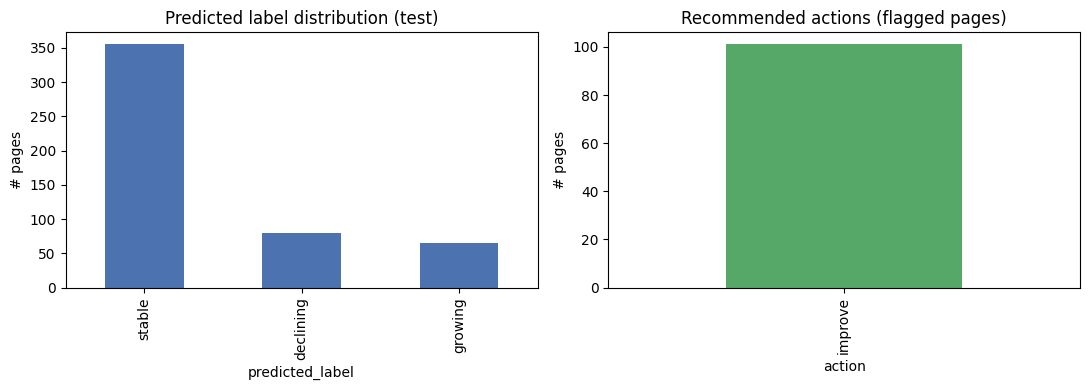

In [6]:
# Chart for the paper: label distribution, model vs baseline accuracy
from _lib import compute_labels as _cl

fig, axes = plt.subplots(1, 2, figsize=(11,4))

test_data["predicted_label"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Predicted label distribution (test)")
axes[0].set_ylabel("# pages")

recommendations["action"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Recommended actions (flagged pages)")
axes[1].set_ylabel("# pages")

plt.tight_layout()
plt.savefig("../docs/assets/summary_charts.png", dpi=150)
plt.show()

## Summary
- Held-out test accuracy and per-class metrics are printed above — carry these
  numbers directly into the paper's Results section, don't re-derive them.
- `ranked_recommendations.csv` is the actual action-engine output: page,
  predicted state, action, reason code, priority score.
- Swap-in point for real data: replace `load_search_data()` in `_lib.py` with
  the real DuckDB `hf://` query — nothing else in this notebook needs to change.